In [7]:
import glob
from PIL import Image
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import torch
import matplotlib.pyplot as plt
import random

train_img_path = '/home/sanama/EEG_dataset/things-eeg/Image_set/train_images/'
folders = glob.glob('/home/sanama/EEG_dataset/things-eeg/Image_set/train_images/*/*')
folders =  [Path(i).stem for i in folders ]
folders.sort()

In [2]:
class BatchGeneratorExternalImages(Dataset):
    def __init__(self, root_path, resize=(64, 64)):
        self.paths = sorted(glob.glob(root_path + "*/*.jpg"))
        self.resize = resize

        if len(self.paths) == 0:
            raise RuntimeError(f"No images found in {root_path}")

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = T.functional.resize(img, self.resize)
        img = torch.from_numpy(np.array(img)).float() / 255.0
        return img

    def __len__(self):
        return len(self.paths)


In [27]:

def sample_images_per_concept(dataset, images_per_concept=4, max_concepts=10, seed=0):
    random.seed(seed)
    samples = []

    num_concepts = len(dataset) // 10
    num_concepts = min(num_concepts, max_concepts)

    for c in range(num_concepts):
        start = c * 10
        end = start + 10
        chosen = random.sample(range(start, end), images_per_concept)

        for idx in chosen:
            samples.append((dataset[idx], idx, c))  # include concept id

    return samples


In [18]:
train_path = "/home/sanama/EEG_dataset/things-eeg/Image_set/train_images/"
train_dataset = BatchGeneratorExternalImages(train_path)

print("Dataset size:", len(train_dataset))

samples = sample_images_per_concept(train_dataset, images_per_concept=2)

Dataset size: 16540


In [28]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_samples(samples, cols=4, figsize_per_cell=3):
    n = len(samples)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(cols * figsize_per_cell, rows * figsize_per_cell))

    for i, (img, idx, concept_id) in enumerate(samples):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img.numpy())
        plt.title(f"c{concept_id} idx{idx}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


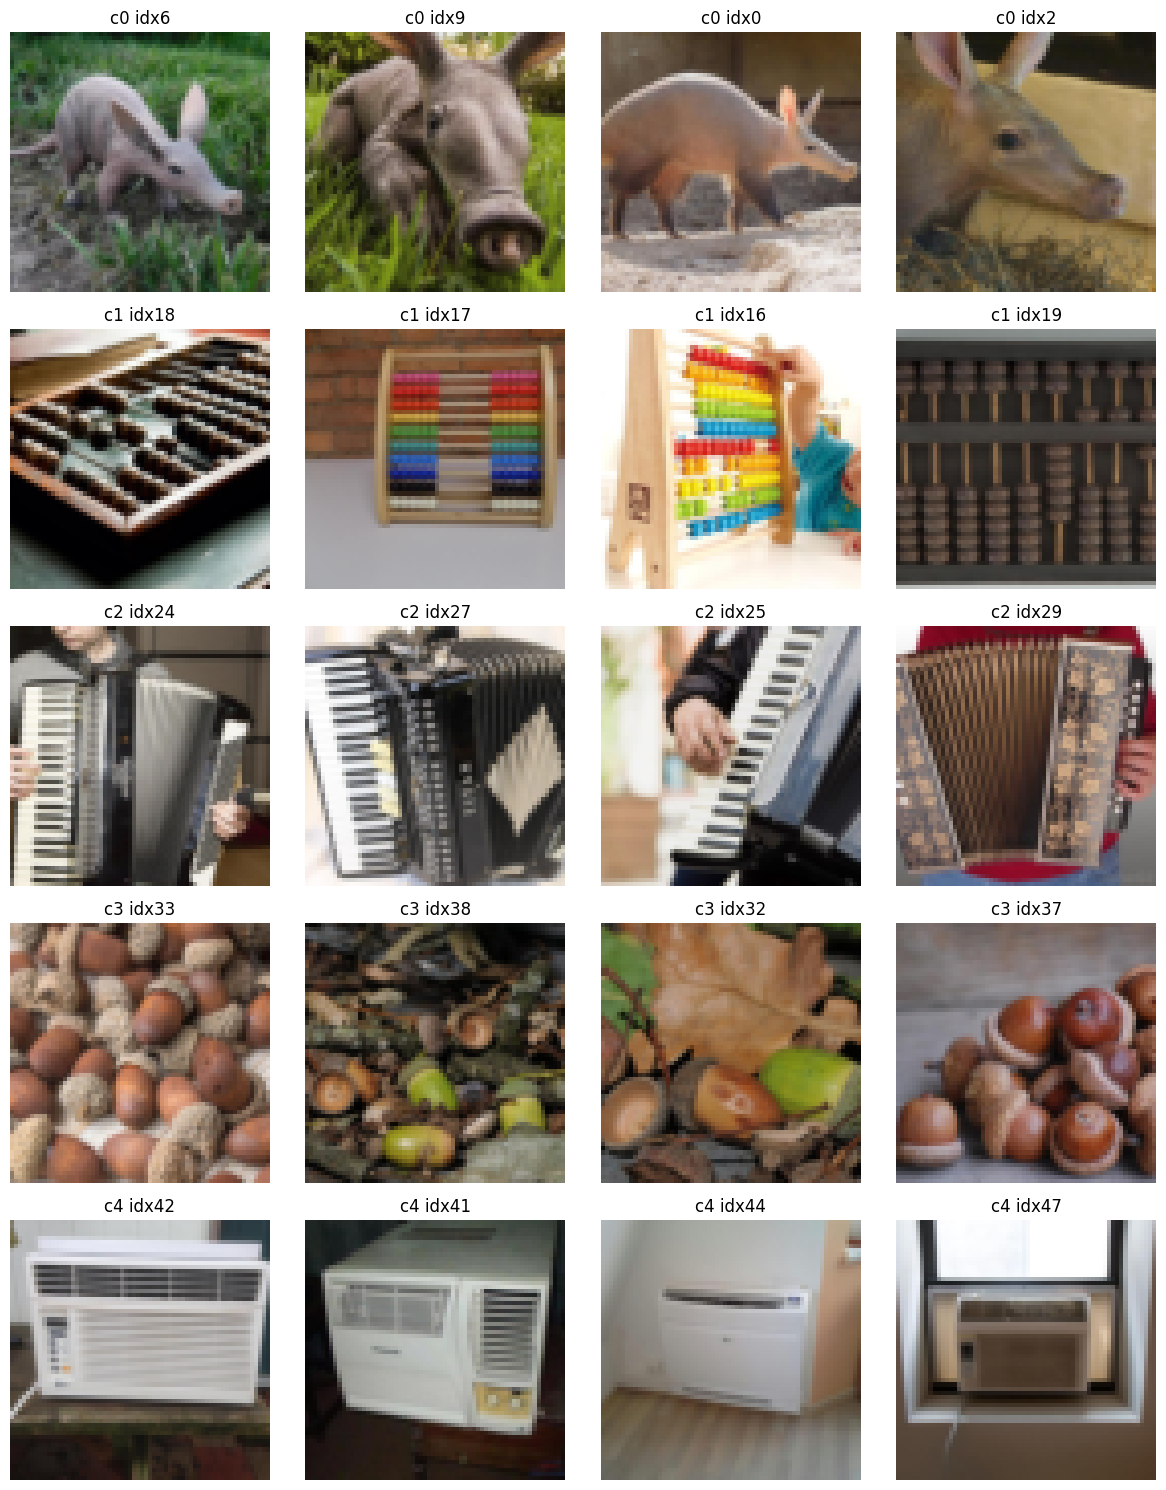

In [30]:
samples = sample_images_per_concept(train_dataset, images_per_concept=4, max_concepts=5)
visualize_samples(samples)
